<a href="https://colab.research.google.com/github/eshghinezhad/DeepLearning/blob/master/Autoencoders/10_Autoencoders_v2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoders

**This notebook contains material adapted from _Hands-On Machine Learning with Scikit-Learn and PyTorch_ by Aurelien Geron (specifically, from the notebook for Chapter 18).** Source materials may be found at [https://github.com/ageron/handson-mlp](https://github.com/ageron/handson-mlp).

# Setup

This project requires Python 3.10 or above:

In [ ]:
import sys

assert sys.version_info >= (3, 10)

Are we using Colab or Kaggle?

In [ ]:
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

If using Colab, the TorchMetrics library is not pre-installed so we must install it manually:

In [ ]:
if IS_COLAB:
    %pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 13.9 MB/s eta 0:00:00


We also need PyTorch ≥ 2.6.0:

In [ ]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

This chapter can be very slow without a hardware accelerator, so if we can find one, let's use it:

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

Let's issue a warning if there's no hardware accelerator available:

In [ ]:
if device == "cpu":
    print("Neural nets can be very slow without a hardware accelerator.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

Neural nets can be very slow without a hardware accelerator.
Go to Runtime > Change runtime and select a GPU hardware accelerator.


As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

We will also be using the same `train()` and `evaluate_tm()` functions as in previous chapters, but with a couple tweaks to the `train()` function:
* Gradient clipping using `torch.nn.utils.clip_grad_norm_()`
* Support for named tuples outputs containing an `output` field (see the lines: `y_pred = y_pred.output if...`)

In [ ]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=2, factor=0.5, epoch_callback=None):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        if epoch_callback is not None:
            epoch_callback(model, epoch)
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f"\rBatch {index + 1}/{len(train_loader)}", end="")
            print(f", loss={total_loss/(index+1):.4f}", end="")
            print(f", {train_metric=:.3f}", end="")
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"\rEpoch {epoch + 1}/{n_epochs},                      "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.3}, "
              f"valid metric: {history['valid_metrics'][-1]:.3}")
    return history

# Performing PCA with an Undercomplete Linear Autoencoder

Let's build the Autoencoder...

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(42)
encoder = nn.Linear(3, 2)
decoder = nn.Linear(2, 3)
autoencoder = nn.Sequential(encoder, decoder).to(device)

Now let's generate the same 3D dataset as we used in Chapter 7:

In [ ]:
# extra code – builds the same 3D dataset as in Chapter 7

import numpy as np
from scipy.spatial.transform import Rotation

def generate_data(m, seed=42):
    X = np.zeros((m, 3))  # initialize 3D dataset
    rng = np.random.default_rng(seed)
    angles = (rng.random(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
    X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
    X += 0.28 * rng.standard_normal((m, 3))  # add more noise
    X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
    X += [0.2, 0, 0.2]  # shift a bit
    return torch.from_numpy(X.astype(np.float32))

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

X_train = generate_data(60, seed=42)
train_set = TensorDataset(X_train, X_train)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

In [ ]:
X_valid = generate_data(500, seed=43)
valid_set = TensorDataset(X_valid, X_valid)
valid_loader = DataLoader(valid_set, batch_size=32)

In [ ]:
import torchmetrics

torch.manual_seed(42)
optimizer = torch.optim.NAdam(autoencoder.parameters(), lr=0.2)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train(autoencoder, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=20)

Epoch 1/20,                      train loss: 0.1621, train metric: 0.406, valid metric: 0.309
Epoch 2/20,                      train loss: 0.0697, train metric: 0.264, valid metric: 0.297
Epoch 3/20,                      train loss: 0.0644, train metric: 0.253, valid metric: 0.324
Epoch 4/20,                      train loss: 0.0935, train metric: 0.303, valid metric: 0.45
Epoch 5/20,                      train loss: 0.1088, train metric: 0.336, valid metric: 0.245
Epoch 6/20,                      train loss: 0.0415, train metric: 0.203, valid metric: 0.235
Epoch 7/20,                      train loss: 0.0426, train metric: 0.205, valid metric: 0.273
Epoch 8/20,                      train loss: 0.0470, train metric: 0.218, valid metric: 0.211
Epoch 9/20,                      train loss: 0.0314, train metric: 0.179, valid metric: 0.213
Epoch 10/20,                      train loss: 0.0300, train metric: 0.174, valid metric: 0.209
Epoch 11/20,                      train loss: 0.0300, train 

In [ ]:
codings = encoder(X_train.to(device))

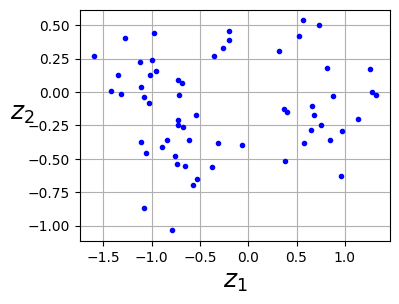

In [ ]:
fig = plt.figure(figsize=(4,3))
codings_np = codings.cpu().detach().numpy()
plt.plot(codings_np[:,0], codings_np[:, 1], "b.")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid(True)

plt.show()

# Stacked Autoencoders

## Implementing a Stacked Autoencoder Using PyTorch

Let's build and train a stacked Autoencoder with 3 hidden layers and 1 output layer (i.e., 2 stacked Autoencoders).

In [ ]:
torch.manual_seed(42)  # extra code – ensures reproducibility

stacked_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 32), nn.ReLU(),
)
stacked_decoder = nn.Sequential(
    nn.Linear(32, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
stacked_ae = nn.Sequential(stacked_encoder, stacked_decoder).to(device)

Let's load the fashion MNIST dataset, and split it into a training set, a validation set, and a test set:

In [ ]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.6MB/s]


In [ ]:
from torch.utils.data import Dataset

class AutoencoderDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, _ = self.base_dataset[idx]
        return x, x

train_loader = DataLoader(AutoencoderDataset(train_data), batch_size=32,
                          shuffle=True)
valid_loader = DataLoader(AutoencoderDataset(valid_data), batch_size=32)
test_loader = DataLoader(AutoencoderDataset(test_data), batch_size=32)

In [ ]:
optimizer = torch.optim.NAdam(stacked_ae.parameters(), lr=0.01)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train(stacked_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch 1/10,                      train loss: 0.0254, train metric: 0.159, valid metric: 0.143
Epoch 2/10,                      train loss: 0.0198, train metric: 0.141, valid metric: 0.136
Epoch 3/10,                      train loss: 0.0186, train metric: 0.136, valid metric: 0.134
Epoch 4/10,                      train loss: 0.0180, train metric: 0.134, valid metric: 0.133
Epoch 5/10,                      train loss: 0.0159, train metric: 0.126, valid metric: 0.128
Epoch 6/10,                      train loss: 0.0155, train metric: 0.125, valid metric: 0.126
Epoch 7/10,                      train loss: 0.0153, train metric: 0.124, valid metric: 0.125
Epoch 8/10,                      train loss: 0.0145, train metric: 0.12, valid metric: 0.122
Epoch 9/10,                      train loss: 0.0143, train metric: 0.12, valid metric: 0.121
Epoch 10/10,                      train loss: 0.0142, train metric: 0.119, valid metric: 0.12


## Visualizing the Reconstructions

This function processes a few validation images through the autoencoder and displays the original images and their reconstructions:

In [ ]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0).cpu(), cmap="binary")
    plt.axis("off")

def plot_reconstructions(model, images, n_images=5):
    images = images[:n_images]
    with torch.no_grad():
        y_pred = model(images.to(device))
    if isinstance(y_pred, tuple):
        y_pred = y_pred.output
    fig = plt.figure(figsize=(len(images) * 1.5, 3))
    for idx in range(len(images)):
        plt.subplot(2, len(images), 1 + idx)
        plot_image(images[idx])
        plt.subplot(2, len(images), 1 + len(images) + idx)
        plot_image(y_pred[idx])

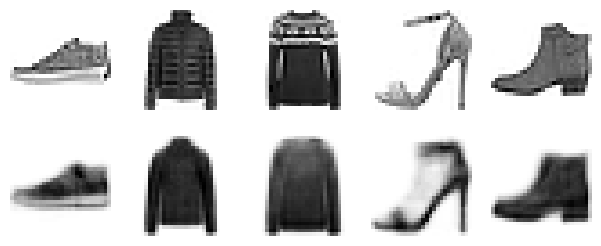

In [ ]:
X_valid = torch.stack([x for x, _ in valid_data])
plot_reconstructions(stacked_ae, X_valid)

plt.show()

The reconstructions look fuzzy, but remember that the images were compressed down to just 32 numbers, instead of 784.

## Using AutoEncoders for Anomaly Detection

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.35MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.89MB/s]


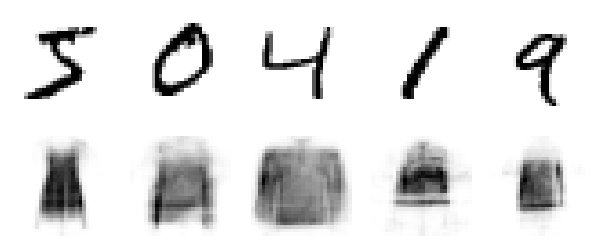

In [ ]:
torch.manual_seed(42)
mnist_data = torchvision.datasets.MNIST(
    root="datasets", train=True, download=True, transform=toTensor)
mnist_images = torch.stack([mnist_data[i][0] for i in range(X_valid.size(0))])
plot_reconstructions(stacked_ae, images=mnist_images)

plt.show()

In [ ]:
images = mnist_images.to(device)
with torch.no_grad():
    y_pred = stacked_ae(images)
    recon_loss = torch.nn.functional.mse_loss(y_pred, images)

recon_loss

tensor(0.0616)

If we compare the reconstruction losses for all Fashion MNIST images and all MNIST images, we can see that the latter are much higher on average:

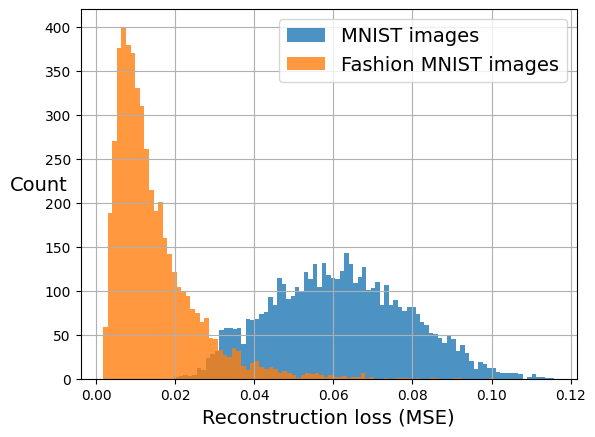

In [ ]:
import torch.nn.functional as F

def compute_reconstruction_losses(X, device):
    X = X.to(device)
    with torch.no_grad():
        y_pred = stacked_ae(X)
        return F.mse_loss(y_pred, X, reduction="none").view(X.size(0), -1).mean(dim=1).cpu()

recon_losses_mnist = compute_reconstruction_losses(mnist_images, device)
recon_losses_fashion_mnist = compute_reconstruction_losses(X_valid, device)

plt.hist(recon_losses_mnist, bins=85, alpha=0.8, label="MNIST images")
plt.hist(recon_losses_fashion_mnist, bins=85, alpha=0.8, label="Fashion MNIST images")
plt.xlabel("Reconstruction loss (MSE)")
plt.ylabel("Count", rotation=0)
plt.legend()
plt.grid()

plt.show()

## Visualizing the Fashion MNIST Dataset

In [ ]:
from sklearn.manifold import TSNE

with torch.no_grad():
    X_valid_compressed = stacked_encoder(X_valid.to(device))

tsne = TSNE(init="pca", learning_rate="auto", random_state=42)
X_valid_2D = tsne.fit_transform(X_valid_compressed.cpu())

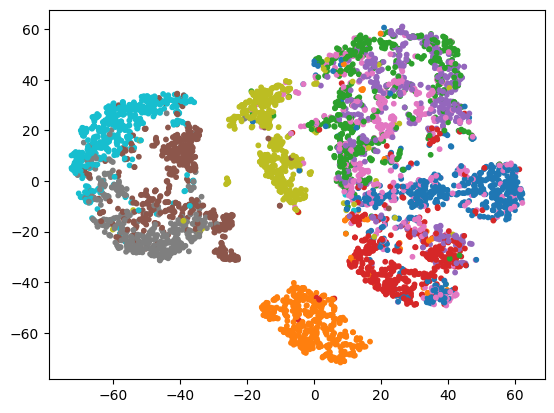

In [ ]:
y_valid = torch.tensor([y for _, y in valid_data])

plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.show()

Let's make this diagram a bit prettier (adapted from [this Scikit-Learn example](https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html)):

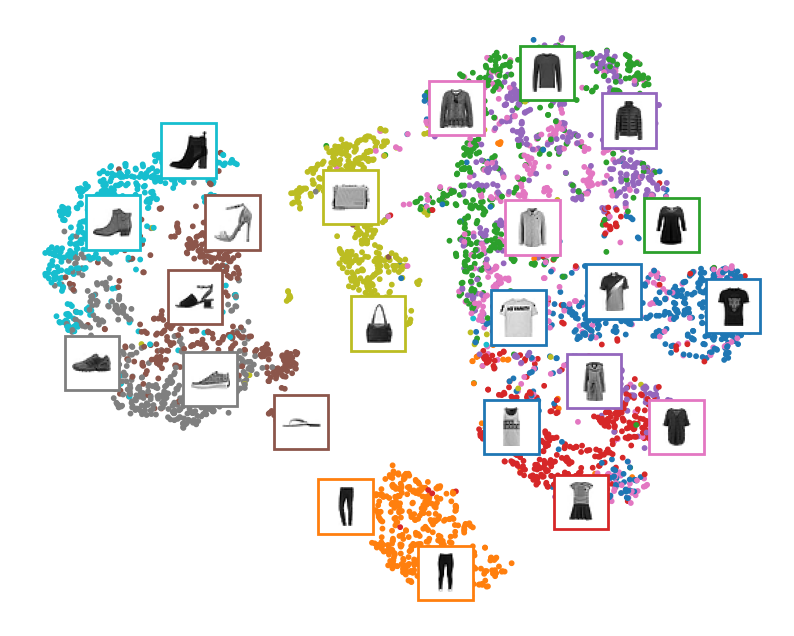

In [ ]:
# extra code – beautifies the previous diagram for the book

import matplotlib as mpl

plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
Z = X_valid_2D
Z = (Z - Z.min()) / (Z.max() - Z.min())  # normalize to the 0-1 range
plt.scatter(Z[:, 0], Z[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(Z):
    dist = ((position - image_positions) ** 2).sum(axis=1)
    if dist.min() > 0.02: # if far enough from other images
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index].squeeze(dim=0),
                                      cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)

plt.axis("off")

plt.show()

## Tying weights

It is common to tie the weights of the encoder and the decoder, by simply using the transpose of the encoder's weights as the decoder weights. For this, we can use a custom module.

In [ ]:
import torch.nn.functional as F

class TiedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(1 * 28 * 28, 128)
        self.enc2 = nn.Linear(128, 32)
        self.dec1_bias = nn.Parameter(torch.zeros(128))
        self.dec2_bias = nn.Parameter(torch.zeros(1 * 28 * 28))

    def encode(self, X):
        Z = X.view(-1, 1 * 28 * 28)  # flatten
        Z = F.relu(self.enc1(Z))
        return F.relu(self.enc2(Z))

    def decode(self, X):
        Z = F.relu(F.linear(X, self.enc2.weight.t(), self.dec1_bias))
        Z = F.sigmoid(F.linear(Z, self.enc1.weight.t(), self.dec2_bias))
        return Z.view(-1, 1, 28, 28)  # unflatten

    def forward(self, X):
        return self.decode(self.encode(X))

In [ ]:
tied_ae = TiedAutoencoder().to(device)
optimizer = torch.optim.NAdam(tied_ae.parameters(), lr=0.01)
history = train(tied_ae, optimizer, mse, rmse, train_loader, valid_loader, n_epochs=10)

Epoch 1/10,                      train loss: 0.0230, train metric: 0.152, valid metric: 0.14
Epoch 2/10,                      train loss: 0.0174, train metric: 0.132, valid metric: 0.133
Epoch 3/10,                      train loss: 0.0167, train metric: 0.129, valid metric: 0.141
Epoch 4/10,                      train loss: 0.0163, train metric: 0.128, valid metric: 0.126
Epoch 5/10,                      train loss: 0.0160, train metric: 0.127, valid metric: 0.126
Epoch 6/10,                      train loss: 0.0158, train metric: 0.126, valid metric: 0.129
Epoch 7/10,                      train loss: 0.0141, train metric: 0.119, valid metric: 0.119
Epoch 8/10,                      train loss: 0.0139, train metric: 0.118, valid metric: 0.119
Epoch 9/10,                      train loss: 0.0137, train metric: 0.117, valid metric: 0.118
Epoch 10/10,                      train loss: 0.0129, train metric: 0.113, valid metric: 0.115


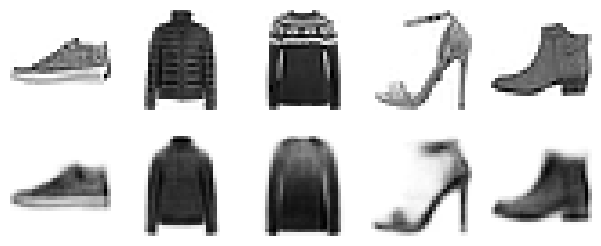

In [ ]:
# extra code – plots reconstructions
plot_reconstructions(tied_ae, X_valid)
plt.show()

## Convolutional Autoencoders

Let's build a stacked Autoencoder with 3 hidden layers and 1 output layer (i.e., 2 stacked Autoencoders).

In [ ]:
torch.manual_seed(42)  # extra code – ensures reproducibility

conv_encoder = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 16 × 14 × 14
    nn.Conv2d(16, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 32 × 7 × 7
    nn.Conv2d(32, 64, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # output: 64 × 3 × 3
    nn.Conv2d(64, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten())  # output: 32

conv_decoder = nn.Sequential(
    nn.Linear(32, 16 * 3 * 3),
    nn.Unflatten(dim=1, unflattened_size=(16, 3, 3)),
    nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
    nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.ReLU(),
    nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1,
                       output_padding=1), nn.Sigmoid())

conv_ae = nn.Sequential(conv_encoder, conv_decoder).to(device)

In [ ]:
optimizer = torch.optim.NAdam(conv_ae.parameters(), lr=0.005)
history = train(conv_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch 1/10,                      train loss: 0.0289, train metric: 0.17, valid metric: 0.143
Epoch 2/10,                      train loss: 0.0168, train metric: 0.13, valid metric: 0.129
Epoch 3/10,                      train loss: 0.0148, train metric: 0.122, valid metric: 0.119
Epoch 4/10,                      train loss: 0.0137, train metric: 0.117, valid metric: 0.118
Epoch 5/10,                      train loss: 0.0123, train metric: 0.111, valid metric: 0.112
Epoch 6/10,                      train loss: 0.0120, train metric: 0.11, valid metric: 0.11
Epoch 7/10,                      train loss: 0.0118, train metric: 0.109, valid metric: 0.109
Epoch 8/10,                      train loss: 0.0113, train metric: 0.106, valid metric: 0.107
Epoch 9/10,                      train loss: 0.0112, train metric: 0.106, valid metric: 0.106
Epoch 10/10,                      train loss: 0.0111, train metric: 0.105, valid metric: 0.106


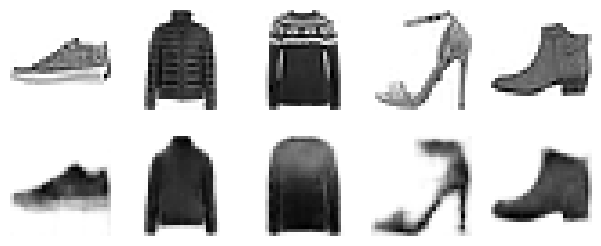

In [ ]:
# extra code – shows the reconstructions
plot_reconstructions(conv_ae, X_valid)
plt.show()

# Extra Material – Recurrent Autoencoders

Let's treat each Fashion MNIST image as a sequence of 28 vectors, each with 28 dimensions:

In [ ]:
class RecurrentAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_lstm = nn.LSTM(input_size=28, hidden_size=128,
                                    num_layers=2, batch_first=True)
        self.encoder_proj = nn.Linear(128, 32)  # Compress to latent vector
        self.decoder_lstm = nn.LSTM(input_size=32, hidden_size=128,
                                    batch_first=True)
        self.decoder_proj = nn.Linear(128, 28)

    def encode(self, X):  # X shape: [B, 1, 28, 28]
        Z = X.squeeze(dim=1)  # Z shape: [B, 28, 28]
        _, (h_n, _) = self.encoder_lstm(Z)  # h_n shape: [2, B, 100]
        Z = h_n[-1]  # get the hidden state of the last layer: [B, 100]
        return self.encoder_proj(Z)  # [B, 30]

    def decode(self, X):
        Z = X.unsqueeze(dim=1).repeat(1, 28, 1)  # [B, 28, 32]
        Z, _ = self.decoder_lstm(Z)  # [B, 28, 100]
        return F.sigmoid(self.decoder_proj(Z).unsqueeze(dim=1)) # [B, 1, 28, 28]

    def forward(self, X):
        return self.decode(self.encode(X))

torch.manual_seed(42)
recurrent_ae = RecurrentAutoencoder().to(device)

In [ ]:
optimizer = torch.optim.NAdam(recurrent_ae.parameters(), lr=1e-3)
history = train(recurrent_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch 1/10,                      train loss: 0.0514, train metric: 0.227, valid metric: 0.176
Epoch 2/10,                      train loss: 0.0241, train metric: 0.155, valid metric: 0.149
Epoch 3/10,                      train loss: 0.0195, train metric: 0.14, valid metric: 0.135
Epoch 4/10,                      train loss: 0.0166, train metric: 0.129, valid metric: 0.126
Epoch 5/10,                      train loss: 0.0143, train metric: 0.12, valid metric: 0.12
Epoch 6/10,                      train loss: 0.0135, train metric: 0.116, valid metric: 0.115
Epoch 7/10,                      train loss: 0.0127, train metric: 0.112, valid metric: 0.112
Epoch 8/10,                      train loss: 0.0119, train metric: 0.109, valid metric: 0.109
Epoch 9/10,                      train loss: 0.0116, train metric: 0.108, valid metric: 0.108
Epoch 10/10,                      train loss: 0.0113, train metric: 0.106, valid metric: 0.107


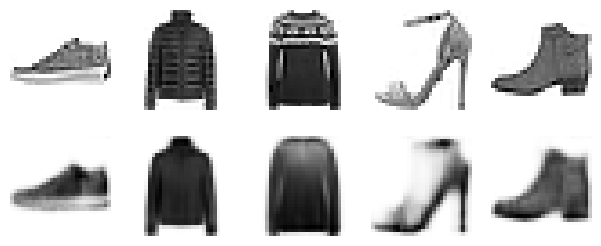

In [ ]:
plot_reconstructions(recurrent_ae, X_valid)
plt.show()

# Denoising Autoencoders

Using dropout:

In [ ]:
torch.manual_seed(42)  # extra code – ensures reproducibility

dropout_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
)
dropout_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
dropout_ae = nn.Sequential(dropout_encoder, dropout_decoder).to(device)

In [ ]:
optimizer = torch.optim.NAdam(dropout_ae.parameters(), lr=0.01)
history = train(dropout_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch 1/10,                      train loss: 0.0282, train metric: 0.168, valid metric: 0.148
Epoch 2/10,                      train loss: 0.0230, train metric: 0.152, valid metric: 0.145
Epoch 3/10,                      train loss: 0.0225, train metric: 0.15, valid metric: 0.144
Epoch 4/10,                      train loss: 0.0223, train metric: 0.149, valid metric: 0.146
Epoch 5/10,                      train loss: 0.0204, train metric: 0.143, valid metric: 0.137
Epoch 6/10,                      train loss: 0.0200, train metric: 0.141, valid metric: 0.137
Epoch 7/10,                      train loss: 0.0198, train metric: 0.141, valid metric: 0.137
Epoch 8/10,                      train loss: 0.0188, train metric: 0.137, valid metric: 0.131
Epoch 9/10,                      train loss: 0.0186, train metric: 0.136, valid metric: 0.131
Epoch 10/10,                      train loss: 0.0185, train metric: 0.136, valid metric: 0.131


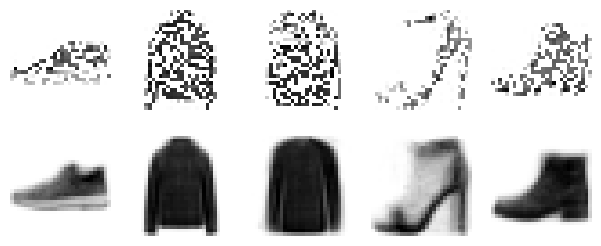

In [ ]:
# extra code – this cell generates Figure 18–9
torch.manual_seed(42)
dropout = nn.Dropout(0.5)
plot_reconstructions(dropout_ae, dropout(X_valid))

plt.show()

Instead of using `Dropout`, we can add Gaussian noise:

In [ ]:
class GaussianNoise(nn.Module):
    def __init__(self, std):
        super().__init__()
        self.std = std

    def forward(self, X):
        if self.training:  # only add noise during training
            noise = torch.randn_like(X) * self.std
            return X + noise
        return X

In [ ]:
torch.manual_seed(42)  # extra code – ensures reproducibility

noise_encoder = nn.Sequential(
    nn.Flatten(),
    GaussianNoise(0.5),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
)
noise_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
noise_ae = nn.Sequential(noise_encoder, noise_decoder).to(device)

In [ ]:
optimizer = torch.optim.NAdam(noise_ae.parameters(), lr=0.01)
history = train(noise_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch 1/10,                      train loss: 0.0292, train metric: 0.171, valid metric: 0.15
Epoch 2/10,                      train loss: 0.0241, train metric: 0.155, valid metric: 0.148
Epoch 3/10,                      train loss: 0.0237, train metric: 0.154, valid metric: 0.146
Epoch 4/10,                      train loss: 0.0235, train metric: 0.153, valid metric: 0.148
Epoch 5/10,                      train loss: 0.0217, train metric: 0.147, valid metric: 0.141
Epoch 6/10,                      train loss: 0.0213, train metric: 0.146, valid metric: 0.14
Epoch 7/10,                      train loss: 0.0211, train metric: 0.145, valid metric: 0.138
Epoch 8/10,                      train loss: 0.0202, train metric: 0.142, valid metric: 0.134
Epoch 9/10,                      train loss: 0.0199, train metric: 0.141, valid metric: 0.134
Epoch 10/10,                      train loss: 0.0198, train metric: 0.141, valid metric: 0.134


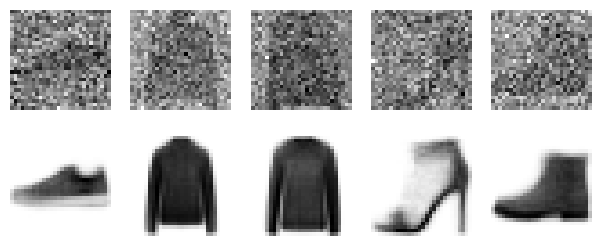

In [ ]:
# extra code
torch.manual_seed(42)
noise = GaussianNoise(0.5)
plot_reconstructions(noise_ae, noise(X_valid))
plt.show()

# Sparse Autoencoder

Let's use the sigmoid activation function in the coding layer. Let's also add $\ell_1$ regularization to it: to do this, we make the module return both the reconstructions and the encodings (i.e., the output of the encoder), so the regularization loss can be computed based on the encodings.

In [ ]:
from collections import namedtuple

AEOutput = namedtuple("AEOutput", ["output", "codings"])

class SparseAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.Sigmoid())
        self.decoder = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))

    def forward(self, X):
        codings = self.encoder(X)
        output = self.decoder(codings)
        return AEOutput(output, codings)

In [ ]:
def mse_plus_sparsity_loss(y_pred, y_target, target_sparsity=0.1,
                           kl_weight=1e-3, eps=1e-8):
    p = torch.tensor(target_sparsity, device=y_pred.codings.device)
    q = torch.clamp(y_pred.codings.mean(dim=0), eps, 1 - eps)  # actual sparsity
    kl_div = p * torch.log(p / q) + (1 - p) * torch.log((1 - p) / (1 - q))
    return mse(y_pred.output, y_target) + kl_weight * kl_div.sum()

Let's plot the KL Divergence loss, versus the MAE and MSE:

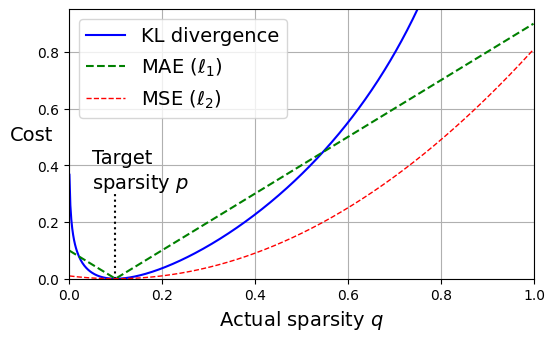

In [ ]:
# extra code – this cell generates Figure 18–10
plt.figure(figsize=(6, 3.5))
p = 0.1
q = np.linspace(0.001, 0.999, 500)
kl_div = p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))
mse_ = (p - q) ** 2
mae = np.abs(p - q)
plt.plot([p, p], [0, 0.3], "k:")
plt.text(0.05, 0.32, "Target\nsparsity $p$", fontsize=14)
plt.plot(q, kl_div, "b-", label="KL divergence")
plt.plot(q, mae, "g--", label=r"MAE ($\ell_1$)")
plt.plot(q, mse_, "r--", linewidth=1, label=r"MSE ($\ell_2$)")
plt.legend(loc="upper left", fontsize=14)
plt.xlabel("Actual sparsity $q$")
plt.ylabel("Cost", rotation=0)
plt.axis([0, 1, 0, 0.95])
plt.grid(True)

Now let's use this regularizer to push the model to have about 10% sparsity in the coding layer:

In [ ]:
torch.manual_seed(42)
sparse_ae = SparseAutoencoder().to(device)
optimizer = torch.optim.NAdam(sparse_ae.parameters(), lr=0.002)
history = train(sparse_ae, optimizer, mse_plus_sparsity_loss, rmse,
                train_loader, valid_loader, n_epochs=10)

Epoch 1/10,                      train loss: 0.0288, train metric: 0.166, valid metric: 0.134
Epoch 2/10,                      train loss: 0.0164, train metric: 0.125, valid metric: 0.12
Epoch 3/10,                      train loss: 0.0135, train metric: 0.114, valid metric: 0.111
Epoch 4/10,                      train loss: 0.0119, train metric: 0.107, valid metric: 0.106
Epoch 5/10,                      train loss: 0.0104, train metric: 0.0999, valid metric: 0.0992
Epoch 6/10,                      train loss: 0.0098, train metric: 0.0975, valid metric: 0.0976
Epoch 7/10,                      train loss: 0.0094, train metric: 0.0953, valid metric: 0.0955
Epoch 8/10,                      train loss: 0.0089, train metric: 0.0927, valid metric: 0.0931
Epoch 9/10,                      train loss: 0.0087, train metric: 0.0917, valid metric: 0.0928
Epoch 10/10,                      train loss: 0.0085, train metric: 0.0907, valid metric: 0.0913


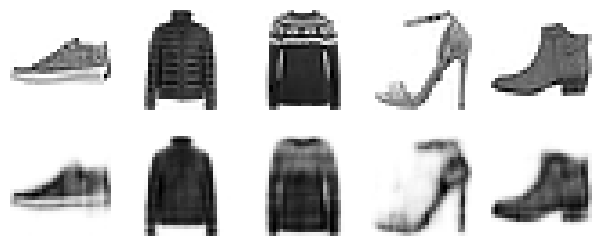

In [ ]:
# extra code – shows the reconstructions
plot_reconstructions(sparse_ae, X_valid)
plt.show()

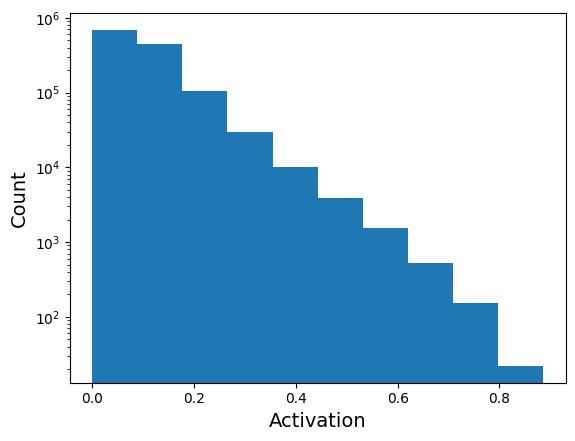

In [ ]:
with torch.no_grad():
    y_pred = sparse_ae(X_valid.to(device))

encs = y_pred.codings.flatten().detach().cpu()
plt.hist(encs, log=True)
plt.xlabel("Activation")
plt.ylabel("Count")
plt.show()

In [ ]:
y_pred.codings.mean()

tensor(0.1001)

Sparse autoencoders often have fairly interpretable codings. For example, here are some images with a high coding #6: they are all shoes (however, it's not always the case when the model is a simple MLP, it's better when the model is a convolutional network).

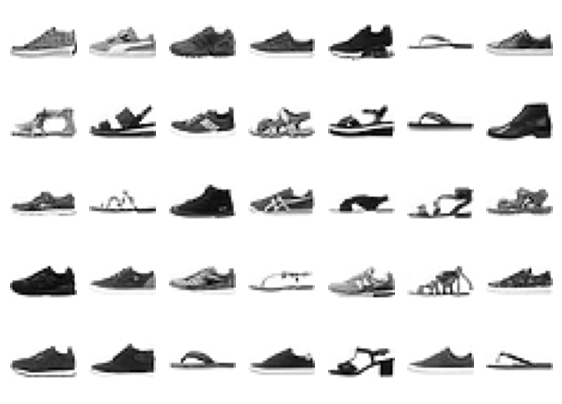

In [ ]:
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plot_image(image)

dim = 6
codings = y_pred.codings[:, dim].cpu()
threshold = np.percentile(codings, 90)
selected_images = X_valid[codings > threshold]
plot_multiple_images(selected_images[:35], 7)
plt.show()

# Variational Autoencoder

In [ ]:
VAEOutput = namedtuple("VAEOutput",
                       ["output", "codings_mean", "codings_logvar"])

class VAE(nn.Module):
    def __init__(self, codings_dim=32):
        super(VAE, self).__init__()
        self.codings_dim = codings_dim
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 2 * codings_dim))  # output both the mean and logvar
        self.decoder = nn.Sequential(
            nn.Linear(codings_dim, 128), nn.ReLU(),
            nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))

    def encode(self, X):
        return self.encoder(X).chunk(2, dim=-1)  # returns (mean, logvar)

    def sample_codings(self, codings_mean, codings_logvar):
        codings_std = torch.exp(0.5 * codings_logvar)
        noise = torch.randn_like(codings_std)
        return codings_mean + noise * codings_std

    def decode(self, Z):
        return self.decoder(Z)

    def forward(self, X):
        codings_mean, codings_logvar = self.encode(X)
        codings = self.sample_codings(codings_mean, codings_logvar)
        output = self.decode(codings)
        return VAEOutput(output, codings_mean, codings_logvar)

In [ ]:
def vae_loss(y_pred, y_target, kl_weight=1.0):
    output, mean, logvar = y_pred
    kl_div = -0.5 * torch.sum(1 + logvar - logvar.exp() - mean.square(), dim=-1)
    return F.mse_loss(output, y_target) + kl_weight * kl_div.mean() / 784

In [ ]:
torch.manual_seed(42)
vae = VAE().to(device)
optimizer = torch.optim.NAdam(vae.parameters(), lr=1e-3)
history = train(vae, optimizer, vae_loss, rmse, train_loader, valid_loader,
                n_epochs=20)

Epoch 1/20,                      train loss: 0.0488, train metric: 0.198, valid metric: 0.175
Epoch 2/20,                      train loss: 0.0371, train metric: 0.166, valid metric: 0.163
Epoch 3/20,                      train loss: 0.0348, train metric: 0.158, valid metric: 0.157
Epoch 4/20,                      train loss: 0.0338, train metric: 0.155, valid metric: 0.155
Epoch 5/20,                      train loss: 0.0330, train metric: 0.152, valid metric: 0.153
Epoch 6/20,                      train loss: 0.0327, train metric: 0.151, valid metric: 0.152
Epoch 7/20,                      train loss: 0.0325, train metric: 0.15, valid metric: 0.151
Epoch 8/20,                      train loss: 0.0322, train metric: 0.149, valid metric: 0.151
Epoch 9/20,                      train loss: 0.0321, train metric: 0.149, valid metric: 0.149
Epoch 10/20,                      train loss: 0.0321, train metric: 0.149, valid metric: 0.149
Epoch 11/20,                      train loss: 0.0319, train 

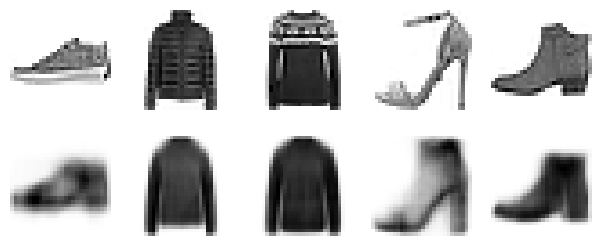

In [ ]:
plot_reconstructions(vae, X_valid)
plt.show()

## Generate Fashion Images

Let's generate a few random codings and decode them:

In [ ]:
torch.manual_seed(42)  # extra code – ensures reproducibility

vae.eval()
codings = torch.randn(3 * 7, vae.codings_dim, device=device)
with torch.no_grad():
    images = vae.decode(codings)

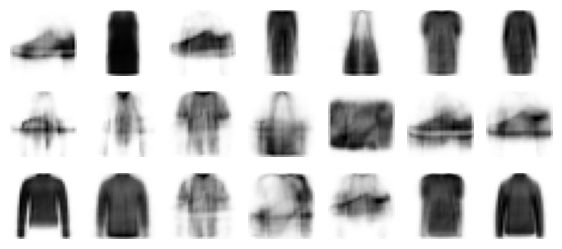

In [ ]:
# extra code – this cells generates Figure 18-12

plot_multiple_images(images, 7)

plt.show()

Now let's perform semantic interpolation between 2 images:

In [ ]:
codings.shape

torch.Size([21, 32])

In [ ]:
torch.manual_seed(111)  # extra code – ensure reproducibility

codings = torch.randn(2, vae.codings_dim)  # start and end codings
n_images = 7
weights = torch.linspace(0, 1, n_images).view(n_images, 1)
codings = torch.lerp(codings[0], codings[1], weights)  # linear interpolation
with torch.no_grad():
    images = vae.decode(codings.to(device))

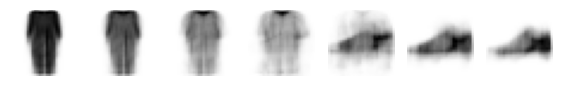

In [ ]:
plot_multiple_images(images)

plt.show()

## Discrete VAE

There's a bug in `F.gumbel_softmax()` on MPS devices (see [PyTorch issue #159103](https://github.com/pytorch/pytorch/issues/159103)) so the code below works around it:

In [ ]:
def gumbel_softmax(logits, tau=1, hard=False, dim=-1):
    if device != "mps":
        return F.gumbel_softmax(logits, tau, hard, dim)
    gumbels = (
        -torch.empty_like(logits, memory_format=torch.legacy_contiguous_format)
        .exponential_()
        .log()
    )  # ~Gumbel(0,1)
    gumbels = torch.clamp(gumbels, -30, 30)  # <<<<<<<<<<<<<<<<<<<<< ADDED
    gumbels = (logits + gumbels) / tau  # ~Gumbel(logits,tau)
    y_soft = gumbels.softmax(dim)

    if hard:
        # Straight through.
        index = y_soft.max(dim, keepdim=True)[1]
        y_hard = torch.zeros_like(
            logits, memory_format=torch.legacy_contiguous_format
        ).scatter_(dim, index, 1.0)
        ret = y_hard - y_soft.detach() + y_soft
    else:
        # Reparametrization trick.
        ret = y_soft
    return ret

In [ ]:
DiscreteVAEOutput = namedtuple("DiscreteVAEOutput",
                               ["output", "logits", "codings_prob"])

class DiscreteVAE(nn.Module):
    def __init__(self, coding_length=32, n_codes=16, temperature=1.0):
        super().__init__()
        self.coding_length = coding_length
        self.n_codes = n_codes
        self.temperature = temperature
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, coding_length * n_codes),
            nn.Unflatten(dim=1, unflattened_size=(coding_length, n_codes)))
        self.decoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(coding_length * n_codes, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1 * 28 * 28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))

    def forward(self, X):
        logits = self.encoder(X)
        codings_prob = gumbel_softmax(logits, tau=self.temperature, hard=True)
        output = self.decoder(codings_prob)
        return DiscreteVAEOutput(output, logits, codings_prob)

**Note**: when computing the Gumbel-Softmax reparameterization, `hard=True` makes the forward pass use a one-hot sample, but the backward pass uses the soft (differentiable) sample.

In [ ]:
def d_vae_loss(y_pred, y_target, kl_weight=1.0):
    output, logits, _ = y_pred
    codings_prob = F.softmax(logits, -1)
    k = logits.new_tensor(logits.size(-1))  # same device and dtype as logits
    kl_div = (codings_prob * (codings_prob.log() + k.log())).sum(dim=(1, 2))
    return F.mse_loss(output, y_target) + kl_weight * kl_div.mean() / 784

In [ ]:
n_epochs = 20
def annealing(model, epoch):
    model.temperature = 1 - 0.9 * epoch / n_epochs

torch.manual_seed(42)
d_vae = DiscreteVAE().to(device)
optimizer = torch.optim.NAdam(d_vae.parameters(), lr=0.001)
history = train(d_vae, optimizer, d_vae_loss, rmse, train_loader, valid_loader,
                n_epochs=n_epochs, epoch_callback=annealing)

/tmp/ipykernel_3846/3538739181.py:3: UserWarning: `eps` parameter is deprecated and has no effect.
  return F.gumbel_softmax(logits, tau, hard, dim)


Epoch 1/20,                      train loss: 0.0582, train metric: 0.229, valid metric: 0.211
Epoch 2/20,                      train loss: 0.0475, train metric: 0.2, valid metric: 0.193
Epoch 3/20,                      train loss: 0.0434, train metric: 0.188, valid metric: 0.185
Epoch 4/20,                      train loss: 0.0415, train metric: 0.183, valid metric: 0.183
Epoch 5/20,                      train loss: 0.0401, train metric: 0.18, valid metric: 0.18
Epoch 6/20,                      train loss: 0.0394, train metric: 0.178, valid metric: 0.178
Epoch 7/20,                      train loss: 0.0389, train metric: 0.177, valid metric: 0.177
Epoch 8/20,                      train loss: 0.0382, train metric: 0.175, valid metric: 0.175
Epoch 9/20,                      train loss: 0.0378, train metric: 0.174, valid metric: 0.175
Epoch 10/20,                      train loss: 0.0376, train metric: 0.173, valid metric: 0.174
Epoch 11/20,                      train loss: 0.0372, train met

In [ ]:
torch.manual_seed(42)  # extra code – ensures reproducibility
n_images = 3 * 7
codings = torch.randint(0, d_vae.n_codes,  # from 0 to k – 1
                        (n_images, d_vae.coding_length), device=device)
codings_prob = F.one_hot(codings, num_classes=d_vae.n_codes).float()
with torch.no_grad():
    images = d_vae.decoder(codings_prob)

Now let's plot these images:

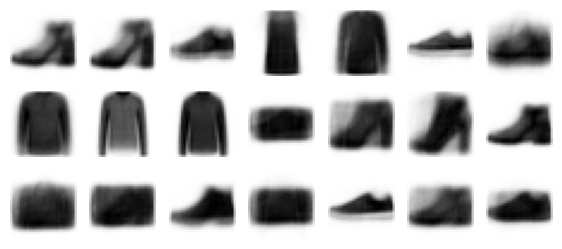

In [ ]:
plot_multiple_images(images, 7)
plt.show()

# Exercise
Pick one of the models above, and try to improve its performance.  Try modifying the network structure, allowing more iterations, etc.